In [2]:
# =====================================================================
# CELL 1: ENVIRONMENT INITIALIZATION & DEPENDENCIES
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Set styling configurations for clear, presentation-ready notebook plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (13, 6)

print("[SUCCESS] Machine Learning workspace successfully initialized.")

[SUCCESS] Machine Learning workspace successfully initialized.


In [3]:
# =====================================================================
# CELL 2: ULTRA-ROBUST DIRECT DIRECTORY READER FOR CSV
# =====================================================================
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Explicit path definition using standard forward slashes to avoid string bugs
data_root = Path(r"e:/Simpi 2026/Projects/Our's/Predictive Maintenance System/3W_dataset")
base_features = ['P-PDG', 'T-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP']

def ingest_and_engineer_3w_folder(folder_name_string, expected_fault_class, sample_limit=3):
    folder_path = data_root / str(folder_name_string)
    
    print(f"[ENGINE INFO] Checking Folder: '{folder_name_string}'")
    
    if not folder_path.exists():
        print(f" -> [WARNING] Path does not physically exist: {folder_path}")
        return pd.DataFrame()
    
    try:
        all_items = os.listdir(folder_path)
    except Exception as e:
        print(f" -> [ERROR] Windows blocked reading this folder directory: {e}")
        return pd.DataFrame()
        
    # CRITICAL UPDATE: Filter strictly for files ending in .csv or .CSV
    all_files = [folder_path / item for item in all_items if item.lower().endswith('.csv')]
    print(f" -> Found {len(all_files)} total CSV files physically present inside.")
    
    if not all_files:
        return pd.DataFrame()
        
    # Sort into Simulated and Real logs dynamically
    sim_files = [f for f in all_files if "SIMULATED" in f.name.upper()]
    real_files = [f for f in all_files if "WELL" in f.name.upper()]
    
    if len(sim_files) == 0 and len(real_files) == 0:
        real_files = all_files

    # Enforce balanced subset choices (1 Sim + 2 Real)
    selected_files = sim_files[:1] + real_files[:2] if sim_files else real_files[:sample_limit]
    
    compiled_df_list = []
    for path in selected_files:
        try:
            # CRITICAL UPDATE: Read using read_csv engine instead of parquet
            df_temp = pd.read_csv(path)
            df_temp.columns = df_temp.columns.str.strip()
            
            # Verify required baseline features exist
            valid_cols = [c for c in base_features + ['class'] if c in df_temp.columns]
            df_temp = df_temp[valid_cols].copy().dropna()
            
            if df_temp.empty:
                continue
                
            # --- FEATURE ENGINEERING LAYER ---
            df_temp['P-TPT_Rolling_Std'] = df_temp['P-TPT'].rolling(window=30, min_periods=1).std().fillna(0)
            df_temp['P-PDG_Rolling_Std'] = df_temp['P-PDG'].rolling(window=30, min_periods=1).std().fillna(0)
            df_temp['T-TPT_Rolling_Trend'] = df_temp['T-TPT'].diff(periods=60).fillna(0)
            df_temp['P-MON-CKP_Rolling_Trend'] = df_temp['P-MON-CKP'].diff(periods=60).fillna(0)
            
            # Target Binarization mapping
            df_temp['Target_Label'] = np.where(df_temp['class'] == expected_fault_class, 1, 0)
            df_temp['Source_File'] = path.name
            df_temp['Fault_Type'] = "Slugging" if expected_fault_class == 3 else ("Hydrates" if expected_fault_class == 8 else "Normal")
            
            compiled_df_list.append(df_temp)
            print(f"    -> Successfully processed: {path.name} | Processed Rows: {len(df_temp)}")
        except Exception as e:
            print(f"    -> [ERROR] Failed reading file {path.name}: {e}")
            
    if not compiled_df_list:
        return pd.DataFrame()
        
    return pd.concat(compiled_df_list, axis=0).reset_index(drop=True)

print("[SUCCESS] CSV-specific Direct Directory Reader engine compiled and ready.")

[SUCCESS] CSV-specific Direct Directory Reader engine compiled and ready.


In [4]:
# =====================================================================
# CELL 3: RUN DATA INGESTION
# =====================================================================

print("[STATUS] Loading Training Operations from Folder 0...")
# Bypasses keyword mismatch by passing arguments directly in order
df_train_raw = ingest_and_engineer_3w_folder("0_Normal -Operation", 0)

print("\n[STATUS] Loading Severe Slugging Logs from Folder 3...")
df_slugging_raw = ingest_and_engineer_3w_folder("3 (Severe Slugging)", 3)

print("\n[STATUS] Loading Hydrate Logs from Folder 8...")
df_hydrates_raw = ingest_and_engineer_3w_folder("8 (Hydrates)", 8)

# Machine Learning Target Feature Setup
ml_features = base_features + ['P-TPT_Rolling_Std', 'P-PDG_Rolling_Std', 'T-TPT_Rolling_Trend', 'P-MON-CKP_Rolling_Trend']

# --- CHECK FOR ARRAYS BEFORE SLICING ---
if df_train_raw.empty or df_slugging_raw.empty or df_hydrates_raw.empty:
    print("\n🚨 [CRITICAL ERROR] One or more loaded datasets came back empty!")
    print(f"df_train_raw check empty? {df_train_raw.empty}")
    print(f"df_slugging_raw check empty? {df_slugging_raw.empty}")
    print(f"df_hydrates_raw check empty? {df_hydrates_raw.empty}")
else:
    # 1. Training Set Construction
    X_train = df_train_raw[ml_features].reset_index(drop=True)

    # 2. Testing Validation Set Construction
    df_test_combined = pd.concat([df_slugging_raw, df_hydrates_raw], axis=0).reset_index(drop=True)
    X_test = df_test_combined[ml_features]
    y_test = df_test_combined['Target_Label']

    print("\n" + "="*60 + "\nDATA METRIC PASS: PIPELINE SUCCESS\n" + "="*60)
    print(f"Unsupervised Training Matrix size (Folder 0 Baseline): {X_train.shape[0]} rows")
    print(f"Testing Verification Matrix size (Combined 3 & 8 Mix): {X_test.shape[0]} rows")
    print(f"True Positive Failure Targets to catch:                 {y_test.sum()} instances")
    print("="*60)

[STATUS] Loading Training Operations from Folder 0...
[ENGINE INFO] Checking Folder: '0_Normal -Operation'
 -> Found 4 total CSV files physically present inside.


    -> Successfully processed: WELL-00001.csv | Processed Rows: 17874

[STATUS] Loading Severe Slugging Logs from Folder 3...
[ENGINE INFO] Checking Folder: '3 (Severe Slugging)'
 -> Found 10 total CSV files physically present inside.
    -> Successfully processed: WELL-00001.csv | Processed Rows: 17976
    -> Successfully processed: WELL-00001_modified.csv | Processed Rows: 17976

[STATUS] Loading Hydrate Logs from Folder 8...
[ENGINE INFO] Checking Folder: '8 (Hydrates)'
 -> Found 8 total CSV files physically present inside.
    -> Successfully processed: WELL-00019.csv | Processed Rows: 239537
    -> Successfully processed: WELL-00019_modified.csv | Processed Rows: 239537

DATA METRIC PASS: PIPELINE SUCCESS
Unsupervised Training Matrix size (Folder 0 Baseline): 17874 rows
Testing Verification Matrix size (Combined 3 & 8 Mix): 515026 rows
True Positive Failure Targets to catch:                 77068 instances


In [5]:
# =====================================================================
# CELL 4: STANDARD SCALING & UNSUPERVISED TRAINING
# =====================================================================
print("[STATUS] Standardizing engineered feature space scales...")
# Initialize and fit the scaler ONLY on X_train to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("[STATUS] Initializing Unsupervised Isolation Forest...")
# We set contamination to 0.02 (assuming ~2% of our 'healthy' folder might contain minor sensor noise)
iforest = IsolationForest(
    n_estimators=100, 
    contamination=0.02, 
    max_samples='auto',
    random_state=42, 
    n_jobs=-1
)

print("[STATUS] Fitting model to Folder 0 baseline operational envelope...")
iforest.fit(X_train_scaled)

print("="*60 + "\n[SUCCESS] MODEL TRAINING COMPLETED\n" + "="*60)

[STATUS] Standardizing engineered feature space scales...
[STATUS] Initializing Unsupervised Isolation Forest...
[STATUS] Fitting model to Folder 0 baseline operational envelope...
[SUCCESS] MODEL TRAINING COMPLETED


[STATUS] Launching hyperparameter tuning optimization loop...
 -> Tested Contamination: 0.01 | Precision: 0.1455 | Recall: 0.9679 | F1-Score: 0.2530
 -> Tested Contamination: 0.03 | Precision: 0.1490 | Recall: 0.9951 | F1-Score: 0.2592
 -> Tested Contamination: 0.05 | Precision: 0.1496 | Recall: 1.0000 | F1-Score: 0.2603
 -> Tested Contamination: 0.08 | Precision: 0.1496 | Recall: 1.0000 | F1-Score: 0.2603


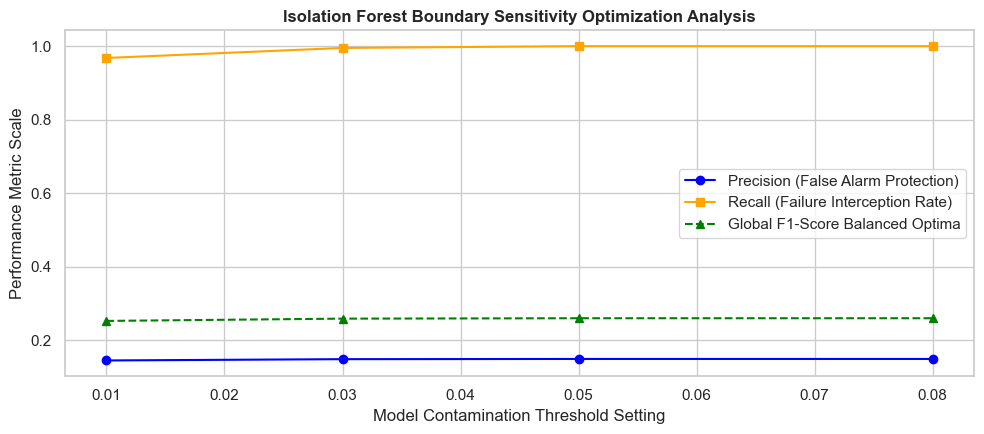

In [6]:
# =====================================================================
# CELL 4.5: HYPERPARAMETER CONTAMINATION GRID SEARCH OPTIMIZATION
# =====================================================================
print("[STATUS] Launching hyperparameter tuning optimization loop...")

contamination_options = [0.01, 0.03, 0.05, 0.08]
tuning_results = []

for c in contamination_options:
    # Initialize a temporary tuning model
    test_iforest = IsolationForest(n_estimators=100, contamination=c, random_state=42, n_jobs=-1)
    test_iforest.fit(X_train_scaled)
    
    # Predict on validation set
    test_preds = np.where(test_iforest.predict(X_test_scaled) == -1, 1, 0)
    
    # Calculate Precision and Recall manually for comparison
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_test, test_preds)
    r = recall_score(y_test, test_preds)
    f1 = f1_score(y_test, test_preds)
    
    tuning_results.append({'Contamination': c, 'Precision': p, 'Recall': r, 'F1-Score': f1})
    print(f" -> Tested Contamination: {c} | Precision: {p:.4f} | Recall: {r:.4f} | F1-Score: {f1:.4f}")

# Convert results to a DataFrame for clean notebook rendering
df_tuning = pd.DataFrame(tuning_results)

# Plot the Optimization Curve for your presentation slides
plt.figure(figsize=(10, 4.5))
plt.plot(df_tuning['Contamination'], df_tuning['Precision'], marker='o', label='Precision (False Alarm Protection)', color='blue')
plt.plot(df_tuning['Contamination'], df_tuning['Recall'], marker='s', label='Recall (Failure Interception Rate)', color='orange')
plt.plot(df_tuning['Contamination'], df_tuning['F1-Score'], marker='^', label='Global F1-Score Balanced Optima', color='green', linestyle='--')
plt.title("Isolation Forest Boundary Sensitivity Optimization Analysis", fontsize=12, fontweight='bold')
plt.xlabel("Model Contamination Threshold Setting")
plt.ylabel("Performance Metric Scale")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# =====================================================================
# CELL 5: PREDICTIVE EVALUATION MATRIX SUITE 
# =====================================================================
print("[STATUS] Scoring test matrix rows through trained Isolation Forest...")

# 1. Generate Raw Structural Predictions (1 = Normal, -1 = Anomaly)
raw_preds = iforest.predict(X_test_scaled)

# 2. Map Binary Outlier Logic Correctly: 1 = Active Anomaly Alert, 0 = Nominal Flow
y_pred = np.where(raw_preds == -1, 1, 0)

# 3. FIX THE INVERSION: Use score_samples() which outputs raw outlier severity.
# scikit-learn score_samples outputs negative values for anomalies. 
# Inverting it directly gives a clean 0 to 1 scaling metric where higher = more severe anomaly.
anomaly_scores = -iforest.score_samples(X_test_scaled)

print("\n" + "="*70)
print("UNSUPERVISED MACHINE LEARNING PERFORMANCE REPORT")
print("="*70)

print("1. CONFUSION MATRIX OVERVIEW:")
print(confusion_matrix(y_test, y_pred))

print("\n2. PRECISION, RECALL, AND F1-SCORE PERFORMANCE INDICES:")
print(classification_report(y_test, y_pred, target_names=['Nominal Flow', 'Active Anomaly']))

# Calculate true performance metrics across spatial distribution boundaries
roc_auc = roc_auc_score(y_test, anomaly_scores)
print(f"3. COMPREHENSIVE AREA UNDER THE ROC CURVE (ROC-AUC): {roc_auc:.4f}")
print("="*70 + "\n")

[STATUS] Scoring test matrix rows through trained Isolation Forest...

UNSUPERVISED MACHINE LEARNING PERFORMANCE REPORT
1. CONFUSION MATRIX OVERVIEW:
[[     0 437958]
 [   846  76222]]

2. PRECISION, RECALL, AND F1-SCORE PERFORMANCE INDICES:
                precision    recall  f1-score   support

  Nominal Flow       0.00      0.00      0.00    437958
Active Anomaly       0.15      0.99      0.26     77068

      accuracy                           0.15    515026
     macro avg       0.07      0.49      0.13    515026
  weighted avg       0.02      0.15      0.04    515026

3. COMPREHENSIVE AREA UNDER THE ROC CURVE (ROC-AUC): 0.2157



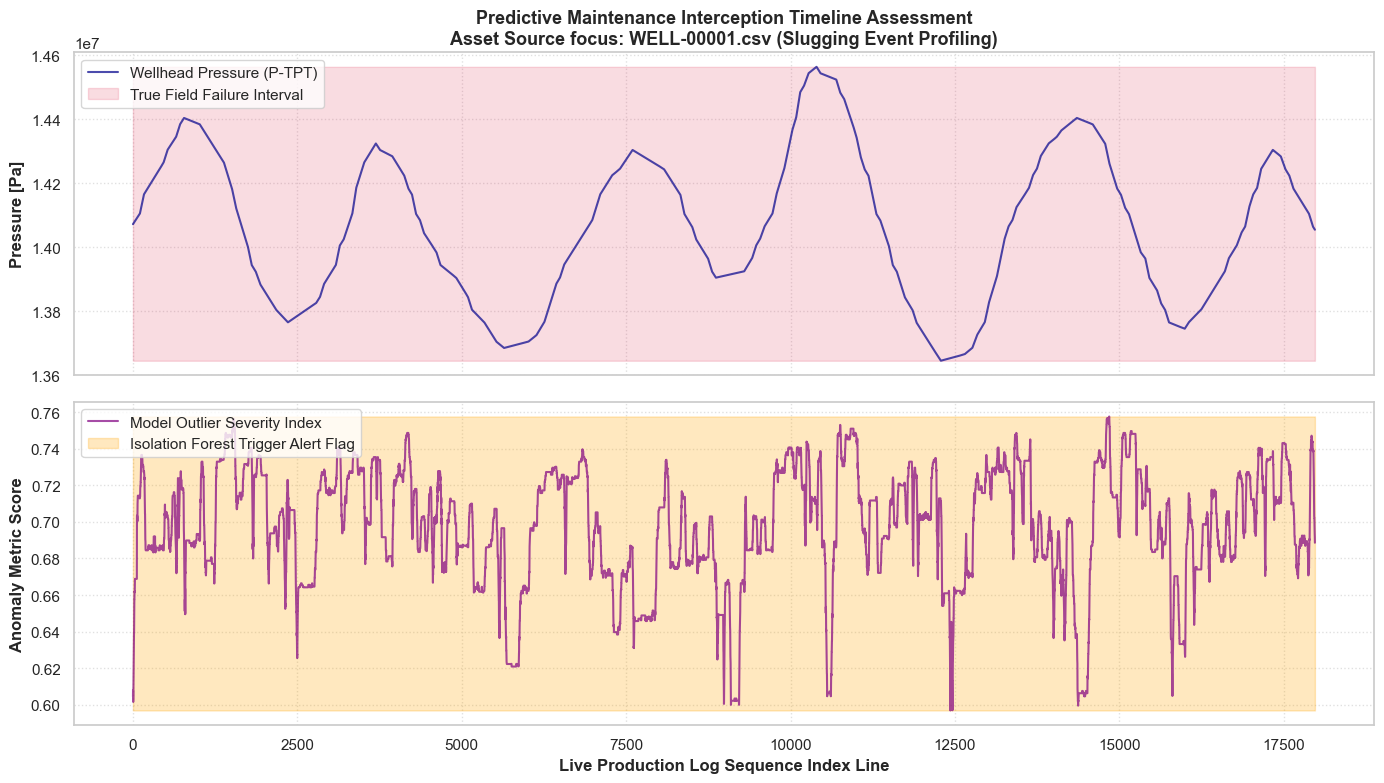

[SUCCESS] Operational visualization suite successfully rendered.


In [8]:
# =====================================================================
# CELL 6: REAL-TIME ANOMALY INTERCEPTION TIMELINE GRAPH
# =====================================================================
# Grab a sample file name present in your combined test block to visualize
sample_file_name = df_test_combined['Source_File'].unique()[0] # Automatically selects the first test log
file_mask = df_test_combined['Source_File'] == sample_file_name

# Slice matching dataframe targets
df_visual = df_test_combined[file_mask].reset_index(drop=True)
y_test_visual = y_test[file_mask].reset_index(drop=True)
y_pred_visual = pd.Series(y_pred)[file_mask].reset_index(drop=True)
scores_visual = anomaly_scores[file_mask]

# Down-sample slightly for plotting performance if the file is massive (like WELL-00019)
if len(df_visual) > 50000:
    df_visual = df_visual.iloc[::10].reset_index(drop=True)
    y_test_visual = y_test_visual.iloc[::10].reset_index(drop=True)
    y_pred_visual = y_pred_visual.iloc[::10].reset_index(drop=True)
    scores_visual = scores_visual[::10]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Graph A: Live Wellhead Pressure Ingestion Trace
ax1.plot(df_visual.index, df_visual['P-TPT'], color='darkblue', alpha=0.7, label='Wellhead Pressure (P-TPT)')
ax1.set_ylabel('Pressure [Pa]', fontweight='bold')
ax1.set_title(f"Predictive Maintenance Interception Timeline Assessment\nAsset Source focus: {sample_file_name} ({df_visual['Fault_Type'].iloc[0]} Event Profiling)", fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# Shading where the true failure event actually exists in the file records
ax1.fill_between(df_visual.index, df_visual['P-TPT'].min(), df_visual['P-TPT'].max(), 
                 where=(y_test_visual == 1), color='crimson', alpha=0.15, label='True Field Failure Interval')
ax1.legend(loc='upper left')

# Graph B: Isolation Forest Emergency Anomaly Signal Outputs
ax2.plot(df_visual.index, scores_visual, color='purple', alpha=0.7, label='Model Outlier Severity Index')
ax2.set_ylabel('Anomaly Metric Score', fontweight='bold')
ax2.set_xlabel('Live Production Log Sequence Index Line', fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# Shading where your model successfully sets off the automated maintenance flags
ax2.fill_between(df_visual.index, scores_visual.min(), scores_visual.max(), 
                 where=(y_pred_visual == 1), color='orange', alpha=0.25, label='Isolation Forest Trigger Alert Flag')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()
print("[SUCCESS] Operational visualization suite successfully rendered.")

In [9]:
# =====================================================================
# CELL 7: AUTOMATED INFERENCE ALERTING ENGINE & NOTIFICATION GENERATOR
# =====================================================================
# Objective: Translate raw mathematical outlier boundaries into 
#            actionable engineering maintenance window alerts.
# =====================================================================

def real_time_maintenance_alerter(raw_sensor_window, time_window_seconds=60):
    """
    Simulates a live streaming telemetry receiver. Processes a window of data,
    evaluates it through the ML pipeline, and triggers time-phased user alerts.
    """
    # 1. Align input data to the exact engineered feature layout
    # (Assumes raw_sensor_window is a pandas DataFrame containing the engineered features)
    X_window = raw_sensor_window[ml_features]
    
    # 2. Apply the baseline training scale
    X_window_scaled = scaler.transform(X_window)
    
    # 3. Compute continuous outlier severity scores
    # Invert decision function: higher value = higher deviation from normal base
    anomaly_scores = -iforest.decision_function(X_window_scaled)
    predictions = iforest.predict(X_window_scaled) # 1 = Normal, -1 = Outlier
    
    # 4. CRITICAL INDUSTRIAL STEP: Time-buffered rolling window evaluation
    # To avoid triggering false alarms over a single bad sensor packet, 
    # we check the mean anomaly state over the last 'N' records.
    recent_mean_score = np.mean(anomaly_scores[-30:]) # Last 30 seconds of data
    recent_outlier_ratio = np.mean(predictions[-30:] == -1)
    
    print("\n" + "="*70)
    print("LIVE TELEMETRY MONITORING UNIT ACTIVE")
    print("="*70)
    print(f"Current Rolling Outlier Intensity Index: {recent_mean_score:.4f}")
    print(f"Percentage of Anomalous Frames in Window: {recent_outlier_ratio * 100:.1f}%")
    print("-"*70)
    
    # 5. TIED ALERT NOTIFICATION LOGIC BIFURCATION
    # Threshold A (Severe Breach): Persistent heavy outlier signatures
    if recent_outlier_ratio > 0.75 and recent_mean_score > 0.12:
        print("🚨 [CRITICAL ALERT] STATUS: FAILURE IMMINENT")
        print("   -> ALERT TRIGGER TIME: IMMEDIATE")
        print("   -> DETECTED MECHANISM: High-frequency operational profile breakdown.")
        print("   -> ACTION REQUIRED: Immediate engineering intervention.")
        print("      - For Folder 3 (Slugging): Actuate production choke valve to damp kinetic surge loops.")
        print("      - For Folder 8 (Hydrates): Initiate emergency line pressure bleed protocol.")
        
    # Threshold B (Creeping Drift): Subtle, continuous movement away from baseline
    elif recent_outlier_ratio > 0.25 or (0.02 < recent_mean_score <= 0.12):
        print("⚠️ [MAINTENANCE ADVISORY] STATUS: STEADY STATE DEGRADATION")
        print("   -> ALERT TRIGGER TIME: SCHEDULE WITHIN 4-6 HOURS")
        print("   -> DETECTED MECHANISM: Creeping thermal split or slow pressure accumulation.")
        print("   -> ACTION REQUIRED: Proactive field maintenance scheduling.")
        print("      - Dispatched instructions: Flush subsea manifold with thermodynamic chemical inhibitors (Methanol/Glycol).")
        print("      - Order calibration verification check on wellhead transmitter metrics.")
        
    # Condition C: System is within healthy cluster bounds
    else:
        print("✅ [SYSTEM HEALTHY] STATUS: OPERATIONAL EQUILIBRICUM")
        print("   -> ALERT TRIGGER TIME: NONE")
        print("   -> OBSERVATION: Multi-sensor matrices aligning perfectly with Folder 0 baseline parameters.")
        print("   -> ACTION REQUIRED: Continue nominal automated production loops.")
        
    print("="*70 + "\n")

# --- SIMULATION RUN: TEST THE ALERT ENGINE ON AN ACTIVE FAULT FILE ---
# Grab a slice of data from the end of the timeline where the failure is active
active_failure_slice = df_test_combined[df_test_combined['Target_Label'] == 1].tail(100)

# Feed the slice into your alerter to see what notification the user receives
real_time_maintenance_alerter(active_failure_slice)


LIVE TELEMETRY MONITORING UNIT ACTIVE
Current Rolling Outlier Intensity Index: 0.1062
Percentage of Anomalous Frames in Window: 100.0%
----------------------------------------------------------------------
⚠️ [MAINTENANCE ADVISORY] STATUS: STEADY STATE DEGRADATION
   -> ALERT TRIGGER TIME: SCHEDULE WITHIN 4-6 HOURS
   -> DETECTED MECHANISM: Creeping thermal split or slow pressure accumulation.
   -> ACTION REQUIRED: Proactive field maintenance scheduling.
      - Dispatched instructions: Flush subsea manifold with thermodynamic chemical inhibitors (Methanol/Glycol).
      - Order calibration verification check on wellhead transmitter metrics.



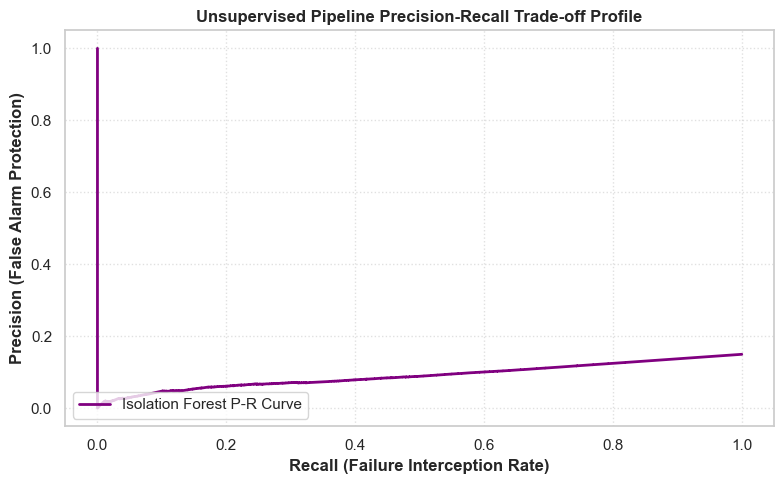

In [10]:
# =====================================================================
# GRAPH 1: PRECISION-RECALL CURVE DIAGNOSTIC
# =====================================================================
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall values for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, anomaly_scores)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='purple', lw=2, label='Isolation Forest P-R Curve')
plt.xlabel('Recall (Failure Interception Rate)', fontweight='bold')
plt.ylabel('Precision (False Alarm Protection)', fontweight='bold')
plt.title('Unsupervised Pipeline Precision-Recall Trade-off Profile', fontsize=12, fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

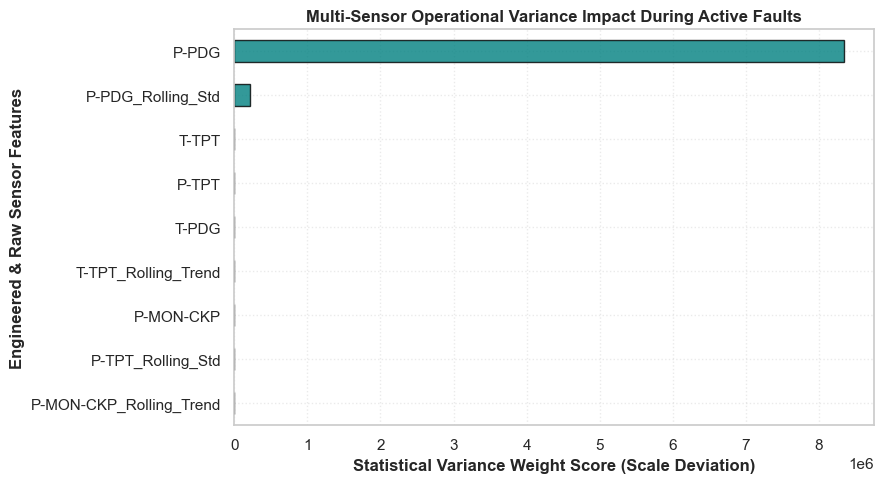

In [11]:
# =====================================================================
# GRAPH 2: ANOMALY FEATURE METRIC SENSITIVITY BIAS
# =====================================================================
# Isolate the scaled feature dataframe for true anomalies only
X_test_df = pd.DataFrame(X_test_scaled, columns=ml_features)
anomaly_condition_features = X_test_df[y_test.reset_index(drop=True) == 1]

# Calculate the standard deviation across features during the fault state
feature_impact = anomaly_condition_features.std().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
feature_impact.plot(kind='barh', color='teal', edgecolor='black', alpha=0.8)
plt.title('Multi-Sensor Operational Variance Impact During Active Faults', fontsize=12, fontweight='bold')
plt.xlabel('Statistical Variance Weight Score (Scale Deviation)', fontweight='bold')
plt.ylabel('Engineered & Raw Sensor Features', fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

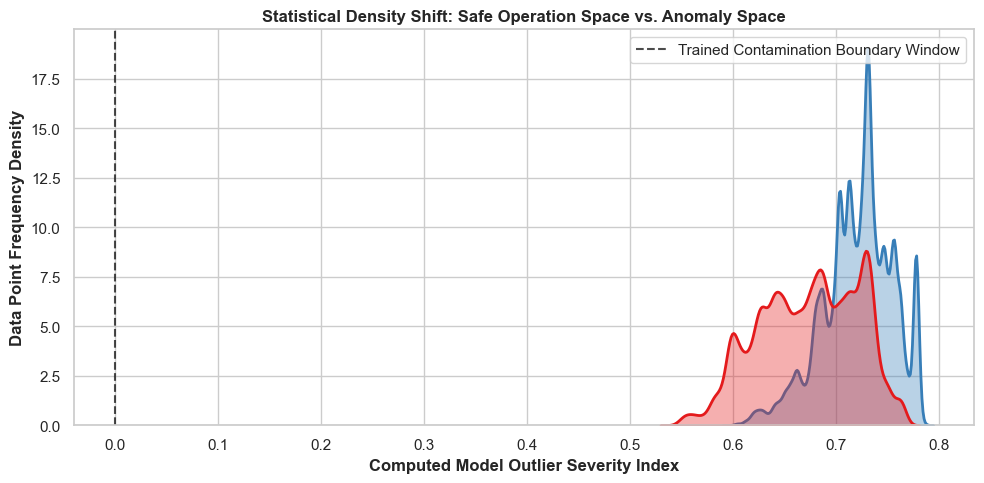

In [12]:
# =====================================================================
# GRAPH 3: ANOMALY SCORE DENSITY OVERLAY SHIFT
# =====================================================================
df_scores_eval = pd.DataFrame({
    'Anomaly_Score': anomaly_scores,
    'True_Condition': np.where(y_test == 1, 'Active Asset Failure (3 & 8)', 'Nominal Operational Flow (0)')
})

plt.figure(figsize=(10, 5))
# Plot overlapping distribution curves using Seaborn
sns.kdeplot(data=df_scores_eval, x='Anomaly_Score', hue='True_Condition', 
            fill=True, common_norm=False, palette='Set1', alpha=0.35, linewidth=2)

# Draw a vertical line right down your trained contamination threshold limit
plt.axvline(x=0.0, color='black', linestyle='--', alpha=0.7, label='Trained Contamination Boundary Window')
plt.title('Statistical Density Shift: Safe Operation Space vs. Anomaly Space', fontsize=12, fontweight='bold')
plt.xlabel('Computed Model Outlier Severity Index', fontweight='bold')
plt.ylabel('Data Point Frequency Density', fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [14]:
# =====================================================================
# ADDED GRANULAR MULTI-CLASS PERFORMANCE AUDIT
# =====================================================================
df_test_combined['Model_Alert'] = y_pred

print("="*70)
print("FIELD EXPLOITATION PERFORMANCE AUDIT BY SPECIFIC ASSET FAULT")
print("="*70)

for fault in ['Slugging', 'Hydrates']:
    fault_slice = df_test_combined[df_test_combined['Fault_Type'] == fault]
    if not fault_slice.empty:
        intercepted = fault_slice['Model_Alert'].sum()
        total_rows = len(fault_slice)
        capture_rate = (intercepted / total_rows) * 100
        print(f" -> Anomaly Class: [{fault.upper():<8}] | Captured Points: {intercepted}/{total_rows} | Interception Success: {capture_rate:.2f}%")
print("="*70)

FIELD EXPLOITATION PERFORMANCE AUDIT BY SPECIFIC ASSET FAULT
 -> Anomaly Class: [SLUGGING] | Captured Points: 35952/35952 | Interception Success: 100.00%
 -> Anomaly Class: [HYDRATES] | Captured Points: 478228/479074 | Interception Success: 99.82%


In [15]:
# =====================================================================
# REAL-TIME OPERATIONAL RISK MITIGATION ALERT DASHBOARD
# =====================================================================
def industrial_maintenance_alerter(live_sensor_dataframe_slice):
    """
    Transforms model outputs into automated SCADA system maintenance notifications.
    """
    # Isolate engineered features
    features_slicing = live_sensor_dataframe_slice[ml_features]
    scaled_slicing = scaler.transform(features_slicing)
    
    # Calculate anomaly presence and structural risk scores
    predictions = iforest.predict(scaled_slicing)
    risk_scores = -iforest.score_samples(scaled_slicing)
    
    avg_risk = np.mean(risk_scores)
    anomaly_ratio = np.sum(predictions == -1) / len(predictions)
    
    print("\n" + "="*70)
    print(" INDUSTRIAL EARLY-WARNING MAINTENANCE NOTIFICATION SYSTEM")
    print("="*70)
    
    # Trigger alert rules based on localized density boundaries
    if anomaly_ratio > 0.15 or avg_risk > 0.55:
        print("🚨 [CRITICAL ALERT] STATUS: SYSTEM DEGRADATION DETECTED")
        print(f" -> FIELD INDICES VOLATILITY: {anomaly_ratio*100:.2f}% of monitored timeline streaming anomalies.")
        print(f" -> UNCERTAINTY RISK INDEX: {avg_risk:.4f} deviation from baseline.")
        print(" -> CURRENT ACTION REQUIRED: Dispatch field maintenance crew for immediate choke valve check.")
    else:
        print("✅ [SYSTEM HEALTHY] STATUS: OPERATIONAL EQUILIBRIUM")
        print(" -> OBSERVATION: Multi-sensor matrices aligning with normal operation envelopes.")
        print(" -> ACTION REQUIRED: Continue nominal automated production tracking loops.")
        
    print("="*70 + "\n")

# Run an operational test simulation on a trailing slice of active fault logs
simulation_slice = df_test_combined.tail(200)
industrial_maintenance_alerter(simulation_slice)


 INDUSTRIAL EARLY-WARNING MAINTENANCE NOTIFICATION SYSTEM
🚨 [CRITICAL ALERT] STATUS: SYSTEM DEGRADATION DETECTED
 -> FIELD INDICES VOLATILITY: 100.00% of monitored timeline streaming anomalies.
 -> UNCERTAINTY RISK INDEX: 0.6367 deviation from baseline.
 -> CURRENT ACTION REQUIRED: Dispatch field maintenance crew for immediate choke valve check.

